# basic backtracking

In [3]:
def backtracking_search(assignment, variables, domains):
    # Goal Test: If all variables are assigned, we are done
    if len(assignment) == len(variables):
        return assignment

    # Select the next unassigned variable (e.g., 'A' then 'B')
    var = [v for v in variables if v not in assignment][0]

    # Try assigning each possible value (Slot 1, Slot 2)
    for value in domains[var]:
        # Constraint Check: New value must not equal any already assigned values
        if value not in assignment.values():
            assignment[var] = value
            
            # Move to the next variable (Recursion)
            result = backtracking_search(assignment, variables, domains)
            
            if result is not None:
                return result
            
            # If it failed later on, Backtrack (remove the assignment)
            del assignment[var]

    return None

# CSP Definition
variables = ['A', 'B']
domains = {
    'A': [1, 2],
    'B': [1, 2]
}

# Run the solver
solution = backtracking_search({}, variables, domains)

if solution:
    print(f"Success! The assignment is: {solution}")
else:
    print("No solution found.")


Success! The assignment is: {'A': 2, 'B': 1}


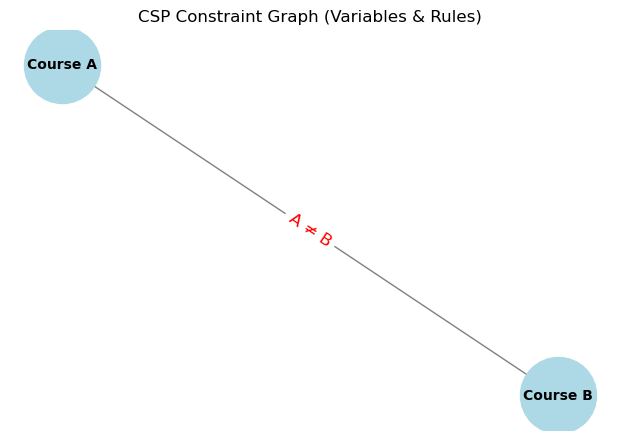

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_constraint_graph():
    # Create a graph object
    G = nx.Graph()

    # 1. Add Variables as Nodes
    nodes = ["Course A", "Course B"]
    G.add_nodes_from(nodes)

    # 2. Add Constraints as Edges
    # The edge represents the "Not Equal" constraint between A and B
    G.add_edge("Course A", "Course B", label="A ≠ B")

    # Set layout for the graph
    pos = nx.spring_layout(G)
    
    plt.figure(figsize=(6, 4))

    # Draw nodes
    nx.draw(G, pos, with_labels=True, node_color='lightblue', 
            node_size=3000, font_size=10, font_weight='bold', edge_color='gray')

    # Draw constraint labels on the edges
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=12)

    plt.title("CSP Constraint Graph (Variables & Rules)")
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    draw_constraint_graph()


# BACKTRACKING WITH CONSTRAINT PROPAGATION

In [4]:
def solve_csp():
    variables = ['A', 'B', 'C']
    # Domains: { 'A': [1, 2], 'B': [1, 2], 'C': [1, 2] }
    domains = {v: [1, 2] for v in variables}
    
    # Define adjacency for constraints: A != B and B != C
    neighbors = {'A': ['B'], 'B': ['A', 'C'], 'C': ['B']}

    def backtrack(assignment, current_domains):
        # Goal check
        if len(assignment) == len(variables):
            return assignment

        # Select the next unassigned variable
        var = [v for v in variables if v not in assignment][0]
        
        for value in current_domains[var]:
            # Check consistency with already assigned neighbors
            consistent = True
            for neighbor in neighbors[var]:
                if neighbor in assignment and assignment[neighbor] == value:
                    consistent = False
                    break
            
            if consistent:
                assignment[var] = value
                
                # --- Constraint Propagation (Forward Checking) ---
                new_domains = {v: list(d) for v, d in current_domains.items()}
                valid_propagation = True
                
                for neighbor in neighbors[var]:
                    if neighbor not in assignment:
                        if value in new_domains[neighbor]:
                            new_domains[neighbor].remove(value)
                        # If a domain becomes empty, this branch is a dead end
                        if not new_domains[neighbor]:
                            valid_propagation = False
                
                if valid_propagation:
                    result = backtrack(assignment, new_domains)
                    if result: return result
                
                # Backtrack: remove assignment if it didn't lead to a solution
                del assignment[var]
        
        return None

    return backtrack({}, domains)

solution = solve_csp()
print(f"Final Assignment: {solution}")


Final Assignment: {'A': 1, 'B': 2, 'C': 1}


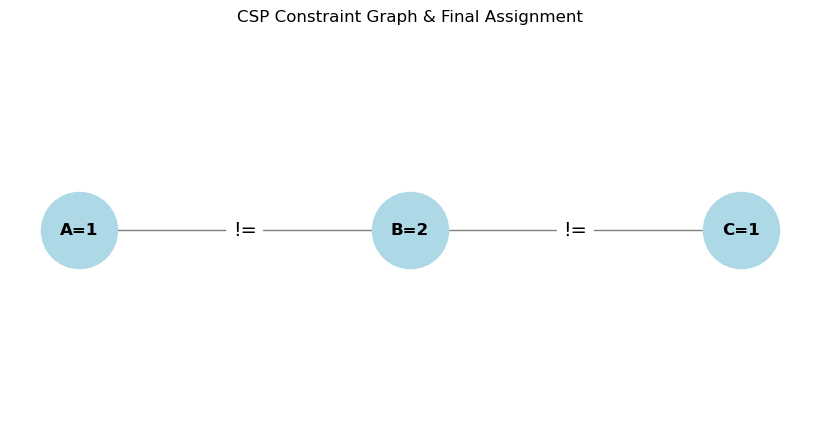

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_constraint_graph():
    # 1. Setup the graph
    G = nx.Graph()
    variables = ['A', 'B', 'C']
    constraints = [('A', 'B'), ('B', 'C')] # Representing A != B and B != C
    
    G.add_nodes_from(variables)
    G.add_edges_from(constraints)

    # 2. Styling
    pos = {'A': (0, 0), 'B': (1, 0), 'C': (2, 0)} # Linear layout
    plt.figure(figsize=(8, 4))
    
    # Draw nodes with their final assigned values from your code
    node_labels = {'A': 'A=1', 'B': 'B=2', 'C': 'C=1'}
    
    nx.draw(G, pos, with_labels=True, labels=node_labels, 
            node_color='lightblue', node_size=3000, 
            font_size=12, font_weight='bold', edge_color='gray')

    # 3. Add constraint labels on edges
    edge_labels = {('A', 'B'): '!=', ('B', 'C'): '!='}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=14)

    plt.title("CSP Constraint Graph & Final Assignment")
    plt.show()

draw_constraint_graph()
